In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Dataset Loading

The Mushroom dataset is loaded into the notebook using the Pandas library. 
This dataset contains information about different mushroom characteristics and their class labels.

Loading the dataset is the first step in machine learning workflow, allowing further preprocessing, analysis, and model building.

In [4]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,classification_report, confusion_matrix
from sklearn.svm import SVC

df=pd.read_csv('mushroom.csv')
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


## Dataset Information

The dataset information provides details about:
- Column names
- Number of non-null values
- Data types of each feature

This step helps identify categorical and numerical features before preprocessing.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

## Dataset Shape

The shape of the dataset is checked to determine:
- Number of rows
- Number of columns

This helps in understanding the size and dimensionality of the dataset.

In [6]:
df.shape

(2000, 26)

In [7]:
df.columns

Index(['Unnamed: 0', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
       'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='object')

## Statistical Summary

The statistical summary provides important descriptive statistics of the dataset such as:
- Count
- Mean
- Standard deviation
- Minimum value
- Maximum value

This helps in understanding data distribution and feature behavior.

In [8]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


## Checking Missing Values

Missing values are checked to ensure data quality and consistency.

Handling missing values is important because incomplete data may affect model accuracy and performance.

In [9]:
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1024)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(976, 26)

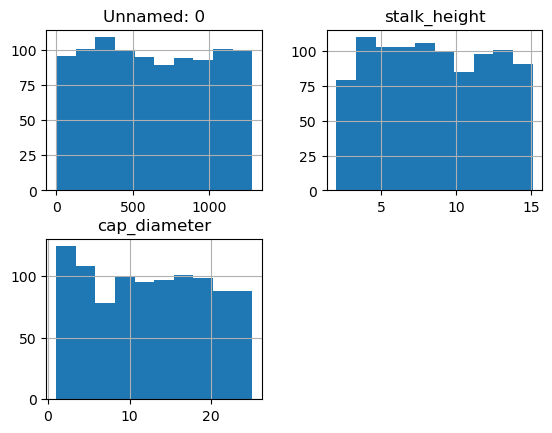

In [13]:
df.hist()
plt.show()

In [14]:
cat_cols=df.select_dtypes('object').columns

In [15]:
cat_cols
for i in cat_cols:
    print(df[i].value_counts())
    

cap_shape
sunken     216
flat       199
conical    193
bell       187
convex     181
Name: count, dtype: int64
cap_surface
scaly      292
smooth     238
fibrous    233
grooves    213
Name: count, dtype: int64
cap_color
brown     127
yellow    114
pink      112
red       110
green     108
gray      105
buff      104
purple    100
white      96
Name: count, dtype: int64
bruises
yes    502
no     474
Name: count, dtype: int64
odor
foul        126
anise       119
fishy       111
musty       111
spicy       110
creosote    107
pungent     101
almond       98
none         93
Name: count, dtype: int64
gill_attachment
free          270
notched       248
attached      244
descending    214
Name: count, dtype: int64
gill_spacing
crowded    330
close      324
distant    322
Name: count, dtype: int64
gill_size
narrow    498
broad     478
Name: count, dtype: int64
gill_color
green        96
orange       95
purple       88
pink         84
black        84
white        82
brown        80
chocolate    

## Label Encoding

Machine learning algorithms cannot directly process categorical text data. 
Therefore, Label Encoding is applied to convert categorical values into numerical format.

Each category is assigned a unique integer value for model training.

In [16]:
le=LabelEncoder()
df['cap_shape']=le.fit_transform(df['cap_shape'])
for i in cat_cols:
    df[i]=le.fit_transform(df[i])
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,4,2,7,0,1,1,2,0,7,...,0,0,2,6,3,1,5,1,14.276173,5.054983
1,1037,4,0,6,0,1,3,1,1,3,...,1,0,2,6,1,2,5,0,3.952715,19.068319
2,309,3,1,5,1,4,1,1,0,8,...,1,3,2,6,6,0,5,1,9.054265,7.205884
3,282,0,2,4,1,3,3,0,0,6,...,0,3,2,0,4,1,0,1,5.226499,20.932692
4,820,3,3,8,1,5,2,1,1,6,...,1,2,0,4,8,1,4,1,14.037532,12.545245


## Histogram Visualization

Histograms are used to visualize the distribution of dataset features.

This helps in understanding:
- Frequency distribution
- Data spread
- Skewness
- Feature patterns

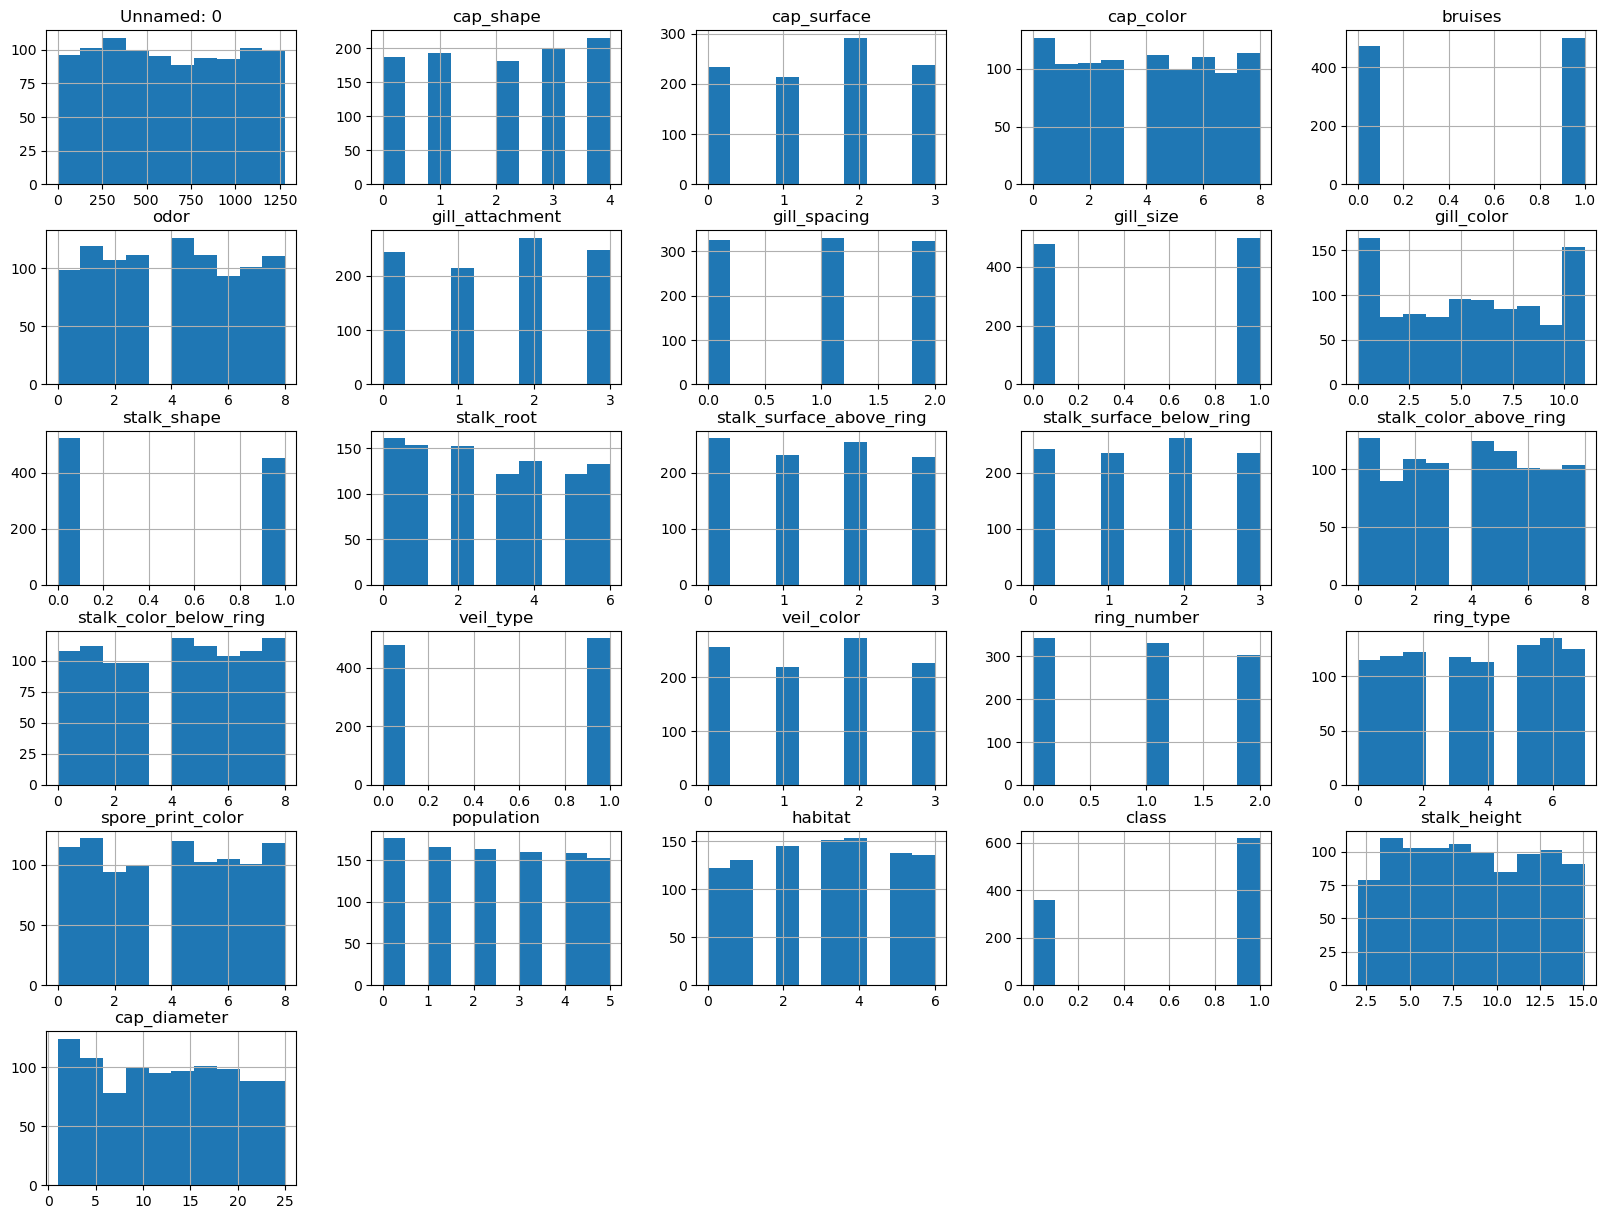

In [17]:
df.hist(figsize=(20,15))
plt.show()

## Box Plot Visualization

Box plots are used to detect:
- Outliers
- Median values
- Quartiles
- Data spread

They provide a clear summary of feature distributions.

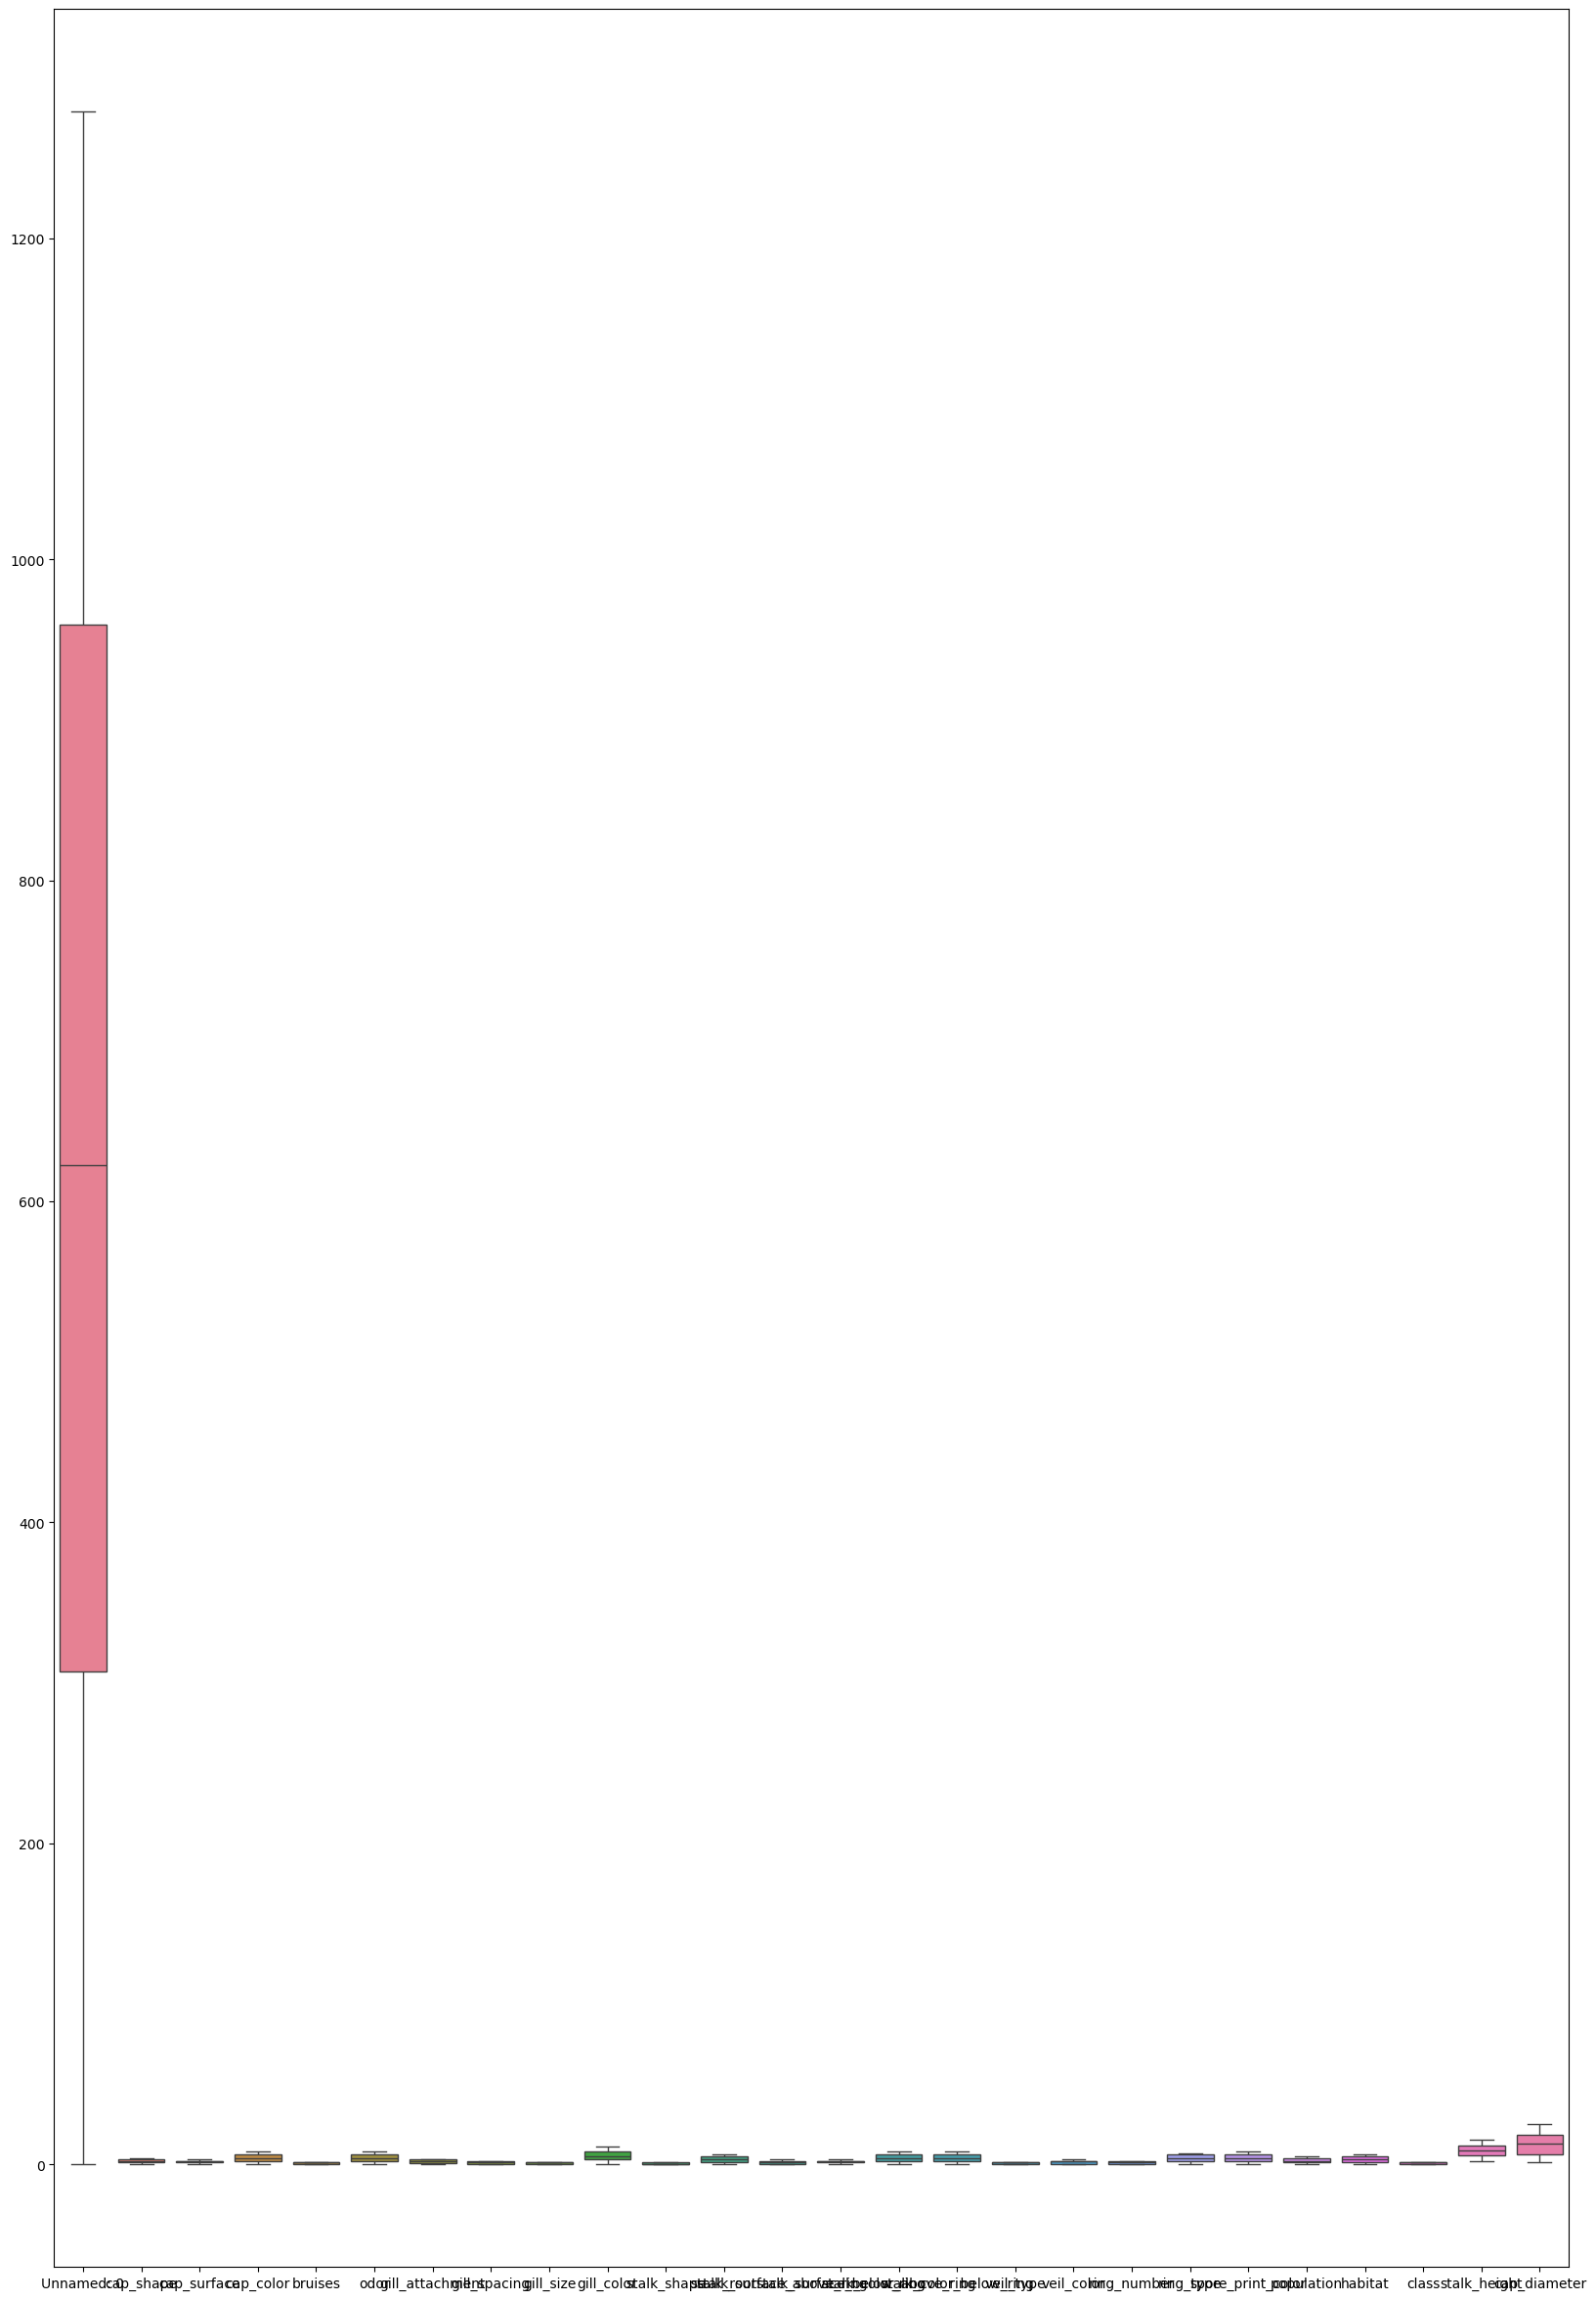

In [18]:
plt.figure(figsize=(20,30))
sns.boxplot(df)
plt.show()

In [19]:
df.skew()

Unnamed: 0                  0.037818
cap_shape                  -0.054468
cap_surface                -0.110914
cap_color                   0.029125
bruises                    -0.057489
odor                        0.051671
gill_attachment            -0.078461
gill_spacing                0.003757
gill_size                  -0.041055
gill_color                 -0.005534
stalk_shape                 0.148172
stalk_root                  0.123944
stalk_surface_above_ring    0.028083
stalk_surface_below_ring   -0.020653
stalk_color_above_ring      0.004589
stalk_color_below_ring     -0.029307
veil_type                  -0.049271
veil_color                 -0.020367
ring_number                 0.073223
ring_type                  -0.051829
spore_print_color           0.014389
population                  0.048660
habitat                    -0.039689
class                      -0.553612
stalk_height                0.045326
cap_diameter                0.029898
dtype: float64

## Correlation Analysis

Correlation analysis is performed to identify relationships between features.

The correlation matrix helps determine:
- Strong positive relationships
- Strong negative relationships
- Independent features

This improves feature understanding and model analysis.

## Heatmap Visualization

A heatmap is used to visually represent the correlation matrix.

Different colors indicate the strength of correlation between features, making it easier to interpret relationships within the dataset.

<function matplotlib.pyplot.show(close=None, block=None)>

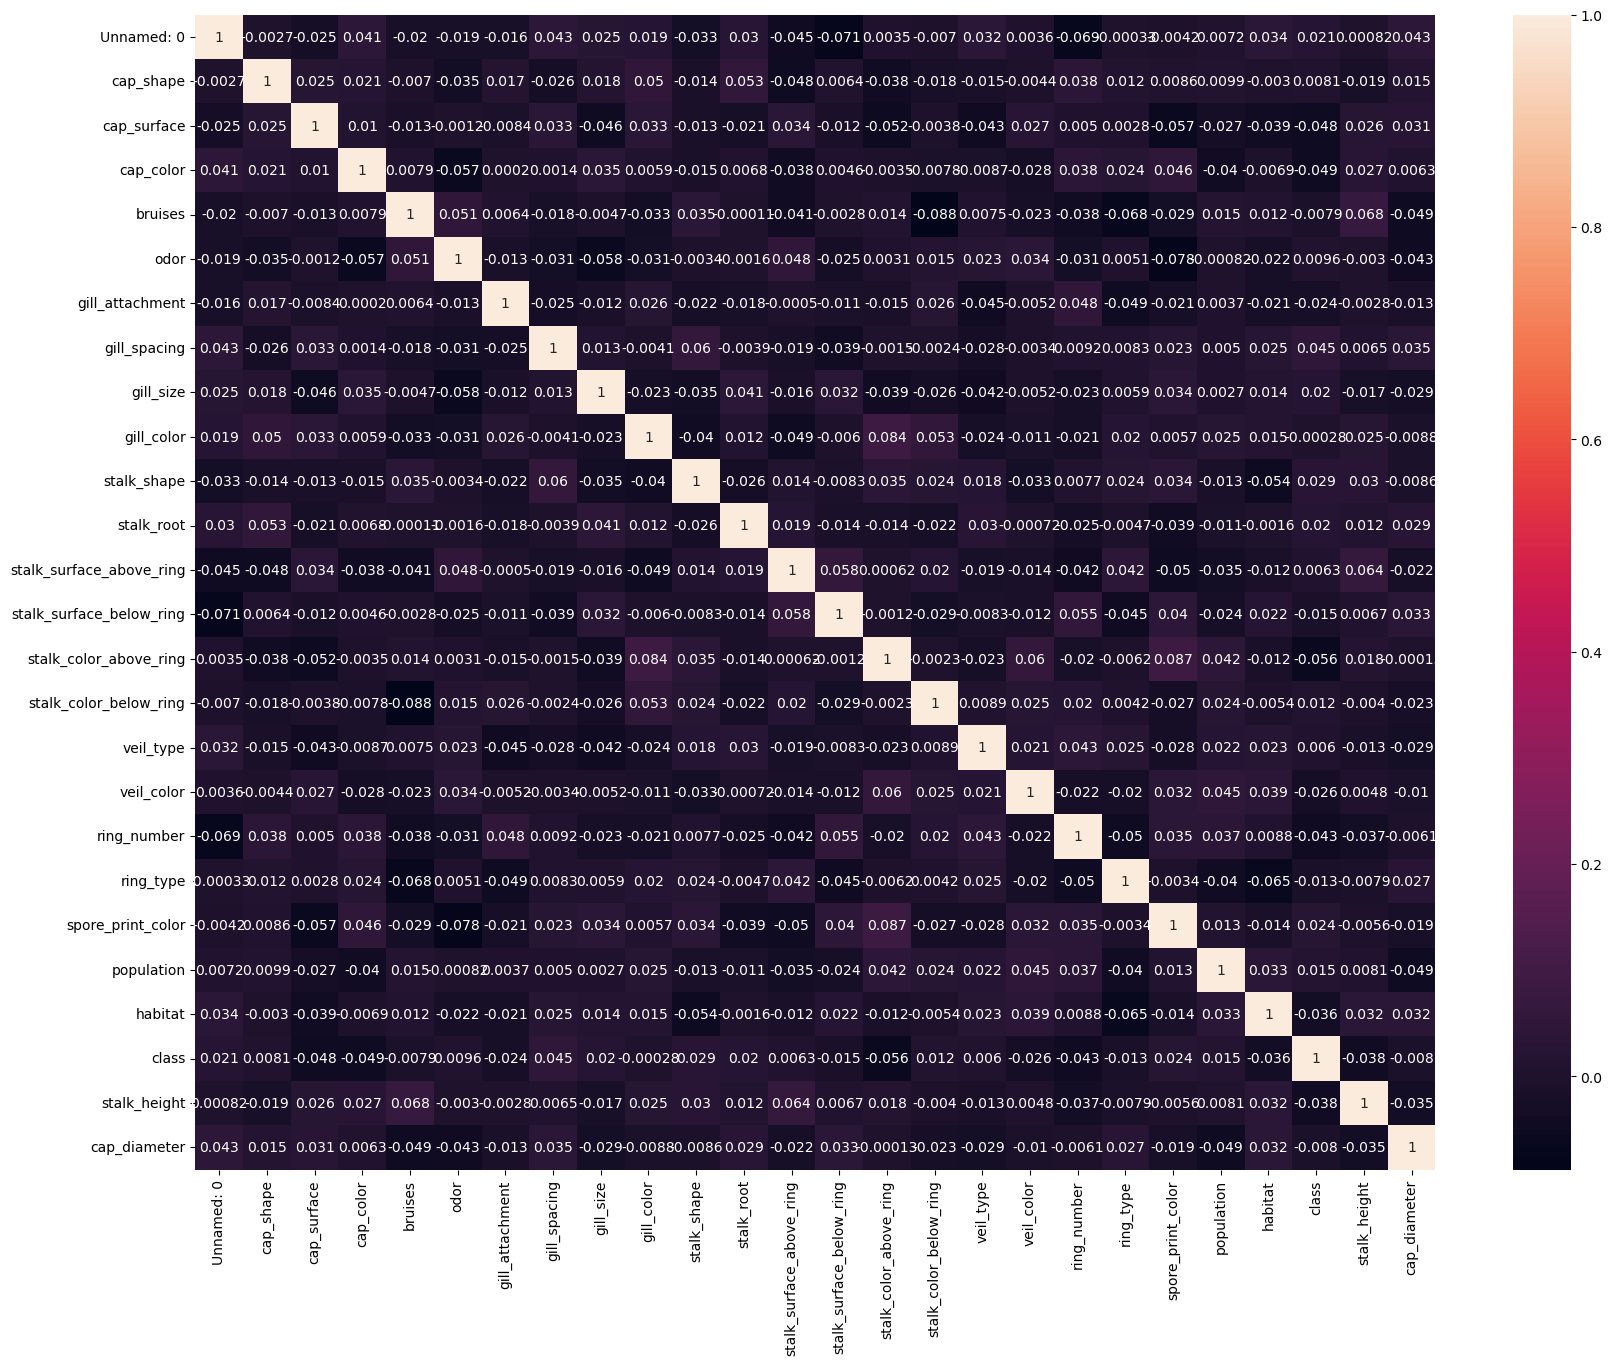

In [20]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show

## Feature Scaling

Feature scaling is applied to normalize the input data so that all features contribute equally during model training.

Scaling improves:
- Model performance
- Convergence speed
- Accuracy of distance-based algorithms like SVM

In [21]:
x=df.drop('class',axis=1)
y=df['class']
ss=StandardScaler()
scaled_x=ss.fit_transform(x)
scaled_x

array([[ 1.43446465,  1.35139853,  0.41028546, ...,  0.99462141,
         1.55397552, -1.08020133],
       [ 1.08507007,  1.35139853, -1.40576266, ...,  0.99462141,
        -1.23528506,  0.92643459],
       [-0.87153954,  0.65279421, -0.4977386 , ...,  0.99462141,
         0.14308581, -0.77220366],
       ...,
       [-0.92529255,  1.35139853,  1.31830952, ..., -1.57622207,
         1.24539141,  0.44984086],
       [ 1.41565109,  1.35139853,  0.41028546, ...,  0.99462141,
        -0.54681571,  0.12936088],
       [ 1.18182549, -0.04581012,  0.41028546, ...,  0.48045272,
         1.22711479,  1.21115202]], shape=(976, 25))

## Feature and Target Variable Separation

The dataset is divided into:
- Independent variables (X)
- Dependent variable (y)

Independent variables are used as input features, while the target variable contains the output class labels.

## Train-Test Splitting

The dataset is divided into training and testing sets.

- Training data is used to train the machine learning model.
- Testing data is used to evaluate model performance on unseen data.

This helps in measuring the generalization capability of the model.

In [22]:
X_train,X_test,y_train,y_test=train_test_split(scaled_x,y,test_size=0.2,random_state=42)

In [23]:
model=SVC()
model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
y_predict=model.predict(X_test)
y_train_predict=model.predict(X_train)
accuracy=accuracy_score(y_test,y_predict)
train_accuracy=accuracy_score(y_train,y_train_predict)
print(train_accuracy)
accuracy

0.7346153846153847


0.6275510204081632

# Parameter Tuning and Optimization

Different SVM hyperparameters such as kernel type and regularization parameter are tested to improve model performance. 
This process helps in selecting the best model configuration for accurate classification.

In [25]:
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]

for kernel in kernels:
    for c in C_values:
        
        model = SVC(kernel=kernel, C=c)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        
        print(f"Kernel={kernel}, C={c}, Accuracy={acc}")

Kernel=linear, C=0.1, Accuracy=0.6326530612244898
Kernel=linear, C=1, Accuracy=0.6326530612244898
Kernel=linear, C=10, Accuracy=0.6326530612244898
Kernel=poly, C=0.1, Accuracy=0.6326530612244898
Kernel=poly, C=1, Accuracy=0.6326530612244898
Kernel=poly, C=10, Accuracy=0.6122448979591837
Kernel=rbf, C=0.1, Accuracy=0.6326530612244898
Kernel=rbf, C=1, Accuracy=0.6275510204081632
Kernel=rbf, C=10, Accuracy=0.47959183673469385


# Comparison of SVM Kernels

This section compares the performance of different SVM kernels such as Linear, Polynomial, and RBF. 
The comparison helps identify which kernel performs best for the Mushroom dataset.

In [26]:
results = {}

for kernel in ['linear', 'poly', 'rbf']:
    
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    results[kernel] = acc

print(results)

{'linear': 0.6326530612244898, 'poly': 0.6326530612244898, 'rbf': 0.6275510204081632}


# Kernel Accuracy Visualization

The accuracy scores of different kernels are visualized using a bar chart for better comparison and interpretation.

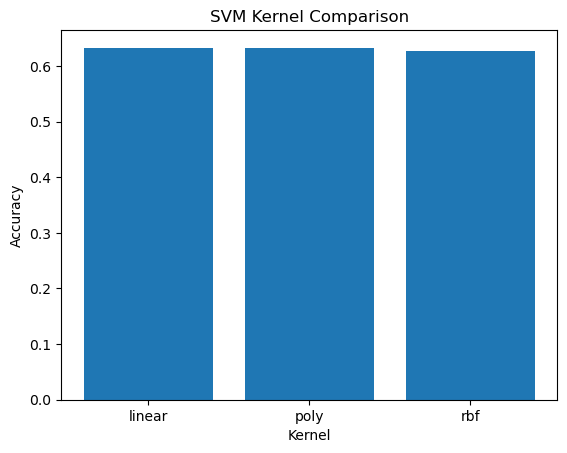

In [27]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())

plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")

plt.show()

# Conclusion

The Support Vector Machine (SVM) algorithm was successfully implemented on the Mushroom dataset. 
Data preprocessing techniques such as encoding categorical variables and train-test splitting were applied before model training.

Different SVM kernels including Linear, Polynomial, and RBF were tested and compared. 
The evaluation metrics demonstrated that SVM performs effectively for mushroom classification tasks.

The confusion matrix and visualizations helped in understanding model performance and classification accuracy. 
Among the tested kernels, the kernel with the highest accuracy can be considered the best-performing model for this dataset.

Overall, SVM is a powerful supervised machine learning algorithm suitable for classification problems with complex decision boundaries.

# Interview Questions and Answers

### 1. What is Support Vector Machine (SVM)?

Support Vector Machine is a supervised machine learning algorithm used for classification and regression tasks. 
It works by finding the optimal hyperplane that separates classes with maximum margin.

### 2. What is a hyperplane in SVM?

A hyperplane is a decision boundary used to separate different classes in the dataset.

### 3. What are support vectors?

Support vectors are the data points closest to the decision boundary. 
They are important because they influence the position of the hyperplane.

### 4. What is the kernel trick in SVM?

The kernel trick allows SVM to transform non-linear data into higher dimensions so that it becomes linearly separable.

### 5. Name different types of kernels used in SVM.

1. Linear Kernel  
2. Polynomial Kernel  
3. Radial Basis Function (RBF) Kernel  
4. Sigmoid Kernel

### 6. What is the role of parameter C in SVM?

The parameter C controls the trade-off between maximizing the margin and minimizing classification error.

### 7. Why is feature scaling important in SVM?

SVM is sensitive to feature magnitudes. 
Feature scaling ensures all features contribute equally during training.

### 8. What evaluation metrics are used for SVM classification?

Common metrics include:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### 9. What are the advantages of SVM?

- Effective in high-dimensional spaces
- Works well with clear margins
- Memory efficient
- Supports multiple kernel functions

### 10. What are the limitations of SVM?

- Slow for large datasets
- Difficult to interpret
- Sensitive to parameter tuning